In [22]:
# mount your google drive to load files directly from there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# if you want to import Python files, add the correct Google Drive directory to your Pythonpath
import sys
sys.path.append('/content/drive/My Drive/Advanced_deep_learning')

In [24]:
# Download the data from huggingface (https://huggingface.co/datasets/simbaswe/galah4/tree/main)
# and upload it to your google drive. Then, specify this directory here
DATA_PATH = '/content/drive/My Drive/Advanced_deep_learning/Exercise_1'

In [64]:
# import the stuff you need. Pytorch is already installed on Google colab
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary
import helper

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"I'm using: {device}")

I'm using: cuda


**Loading the "Spectra" dataset** $\to$ it contains data from measures of star spectra (features) and variables predictable from them (targets)

In [66]:
spectra = np.load(f"{DATA_PATH}/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{DATA_PATH}/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]

In [67]:
print(f'The "Spectra" dataset contains {spectra.shape[0]} spectra each with {spectra.shape[1]} measures.')
print(f'There are {labels.shape[0]} sets of labels') #Check if there are as many labels as spectra

The "Spectra" dataset contains 8914 spectra each with 16384 measures.
There are 8914 sets of labels


In [68]:
# normalize the spectra
spectra = np.log(np.maximum(spectra, 0.2))

In [69]:
#Normalize the labels due to convergence problems

label_mean = labels.mean(axis=0)
label_std = labels.std(axis=0)

labels = (labels - label_mean) / label_std

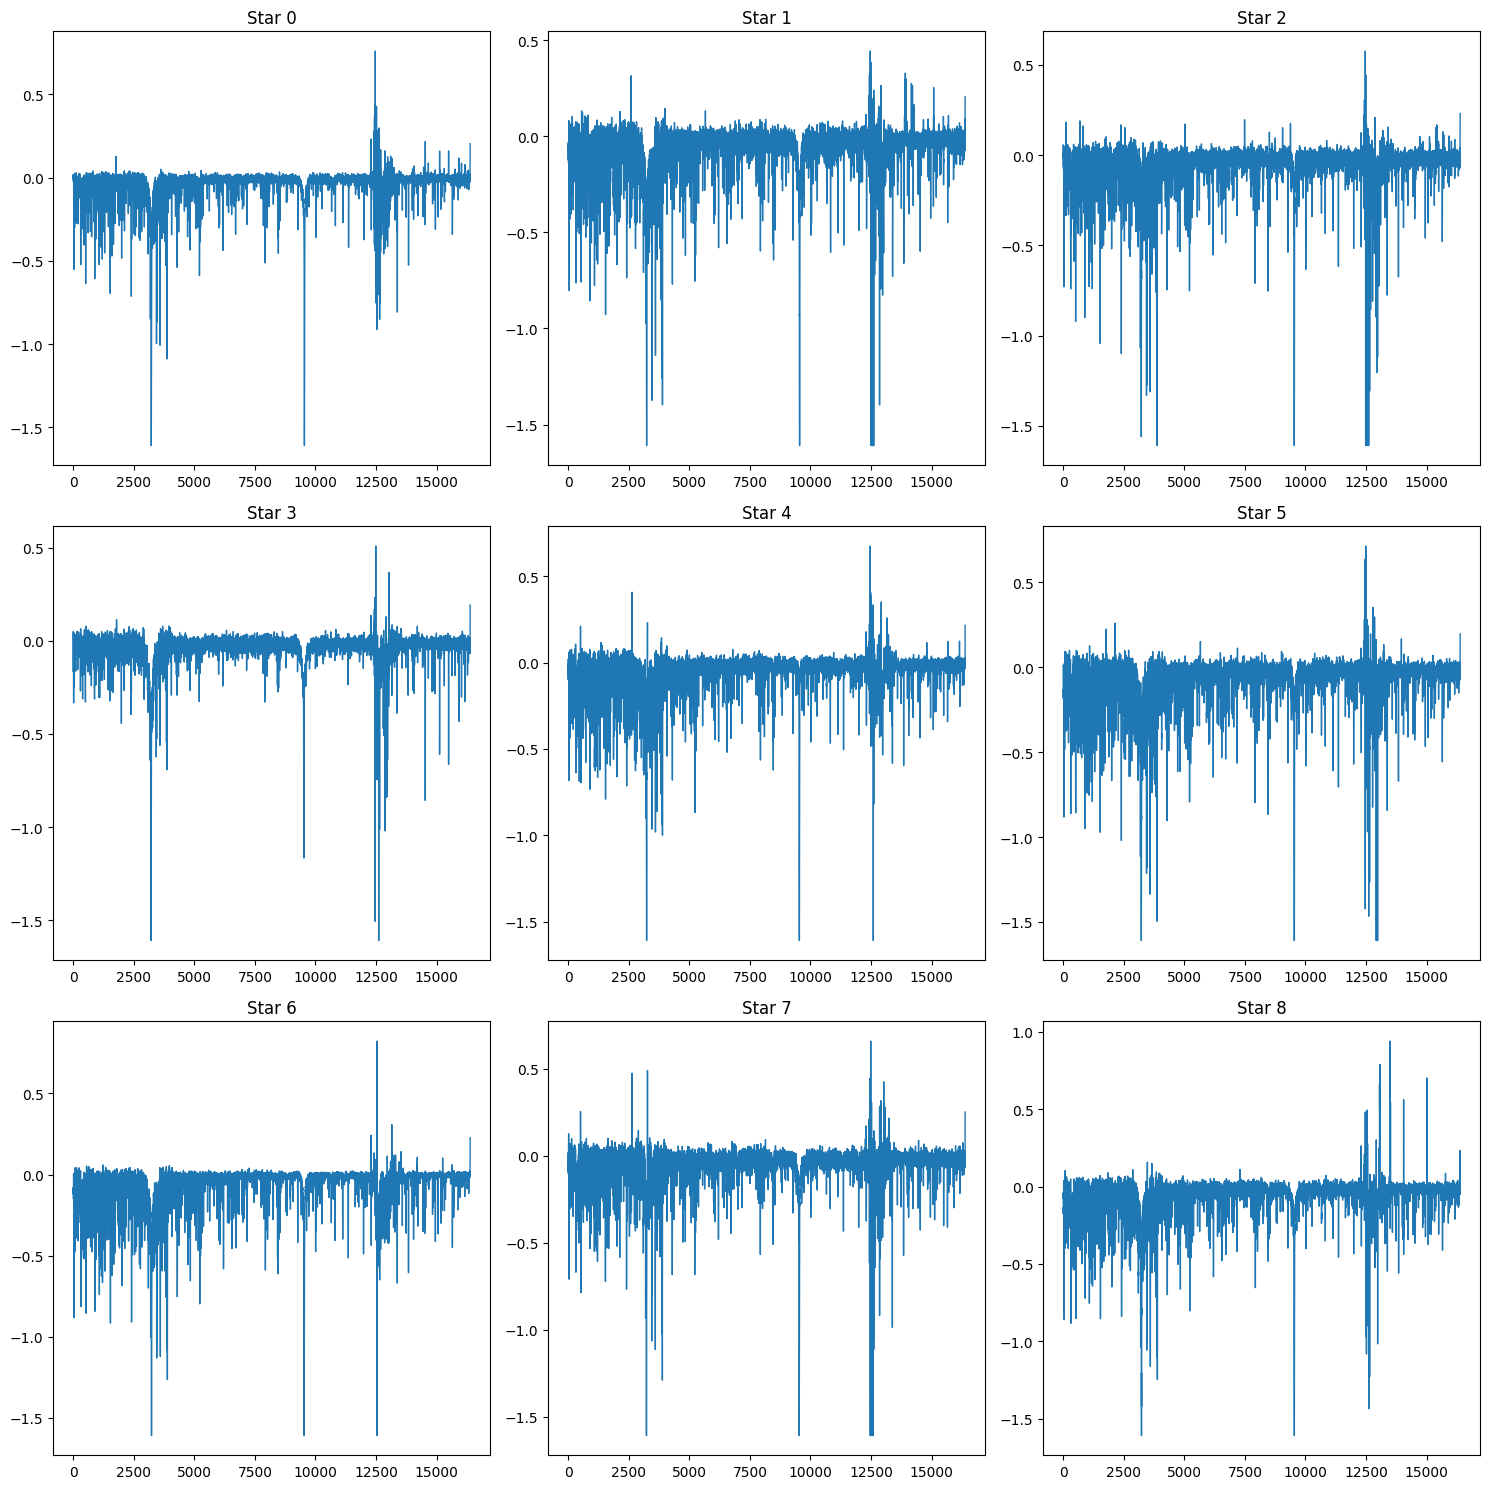

In [70]:
%matplotlib inline

fig, ax = plt.subplots(nrows = 3, ncols=3, figsize=(15, 15))
ax = ax.flatten()

for i in range(9):
  ax[i].plot(spectra[i], lw=1)
  ax[i].set_title(f"Star {i}")
  plt.tight_layout()

**Converting numpay array into PyTorch tensor**

In [71]:
features = torch.from_numpy(spectra)
target = torch.from_numpy(labels)

print(features.device)

cpu


**Implementation of a CustomDataset class** $\to$ this approach allows to manage in a more efficient way the use of the device memory

In [72]:
class CustomDataset(Dataset):
    def __init__(self,X,y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx], self.y[idx]

**Dividing the dataset in train, evaluate and test sets**

In [73]:
dataset = CustomDataset(features, labels)

train_set, eval_set, test_set = random_split(dataset, [0.6, 0.2, 0.2])

In [74]:
batch_size = 128

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
eval_loader = DataLoader(eval_set, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

**Defining the model** $\to$ ad the data are 1-dimensional, 1-dimensional convolutions and poolings are considered. Padding is used, activation function is ReLU. After the convolutional layers data become input of a FCNN for regression. The output layer has 3 neurons.

In [75]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv = nn.Sequential(
        nn.Conv1d(1,32,kernel_size = 15, stride = 2, padding = 0), #Output are 32 tensors of 8185 elements
        nn.ReLU(),
        nn.MaxPool1d(kernel_size = 5), #reduction of dimension 4, output are 32 tensors of 1637 elements
        nn.Conv1d(32,32,kernel_size = 13, padding = 0), #Output are 32 tensors of 1625 elements
        nn.ReLU(),
        nn.MaxPool1d(kernel_size = 5), #Output are 32 tensors of 325 elements
        nn.Conv1d(32,16,kernel_size = 15,padding='same'), #Output are 16 tensors of 325 elements
        nn.ReLU(),
        nn.MaxPool1d(kernel_size = 5), #Output are 16 tensors of 65 elements
        nn.Flatten(),
        nn.Linear(16*65,256), #Start of FCNN
        nn.ReLU(),
        nn.Linear(256,3)
    )

  def forward(self,x):
    return self.conv(x)

model = CNN()
model.to(device) #move model on GPU

print(model)

CNN(
  (conv): Sequential(
    (0): Conv1d(1, 32, kernel_size=(15,), stride=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 32, kernel_size=(13,), stride=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 16, kernel_size=(15,), stride=(1,), padding=same)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=1040, out_features=256, bias=True)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=3, bias=True)
  )
)


**Training** $\to$ being a regression problem a 'Mean Square Error' Loss is considered

In [76]:
N_epochs = 30
learning_rate = 0.001

In [77]:
loss_function = nn.MSELoss()

In [78]:
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [79]:
train_loss = []
eval_loss = []

#-------Training-------
for epoch in range(N_epochs):

  model.train()
  loss_val = []

  for feature, label in train_loader:
    feature = feature.unsqueeze(1).float().to(device) #put data on GPU
    label = label.float().to(device)
    output = model(feature) #model prediction, add the channel dimension so the model doesn't confuse it with the batch size
    loss = loss_function(output, label) #loss computation
    loss_val.append(loss.item())

    optimizer.zero_grad() #clean the gradients computed at previous iteration
    loss.backward() #backpropagation
    optimizer.step() #weights update

  train_loss.append(np.mean(loss_val)) # store mean loss of each epoch

#---------------------
#-------Validation-------
  with torch.no_grad():
    model.eval()
    loss_val = []
    for feature, label in eval_loader:
      feature = feature.unsqueeze(1).float().to(device)
      label = label.float().to(device)
      output = model(feature)
      loss = loss_function(output,label)
      loss_val.append(loss.item())

    eval_loss.append(np.mean(loss_val))

#------------------------



**Validation**

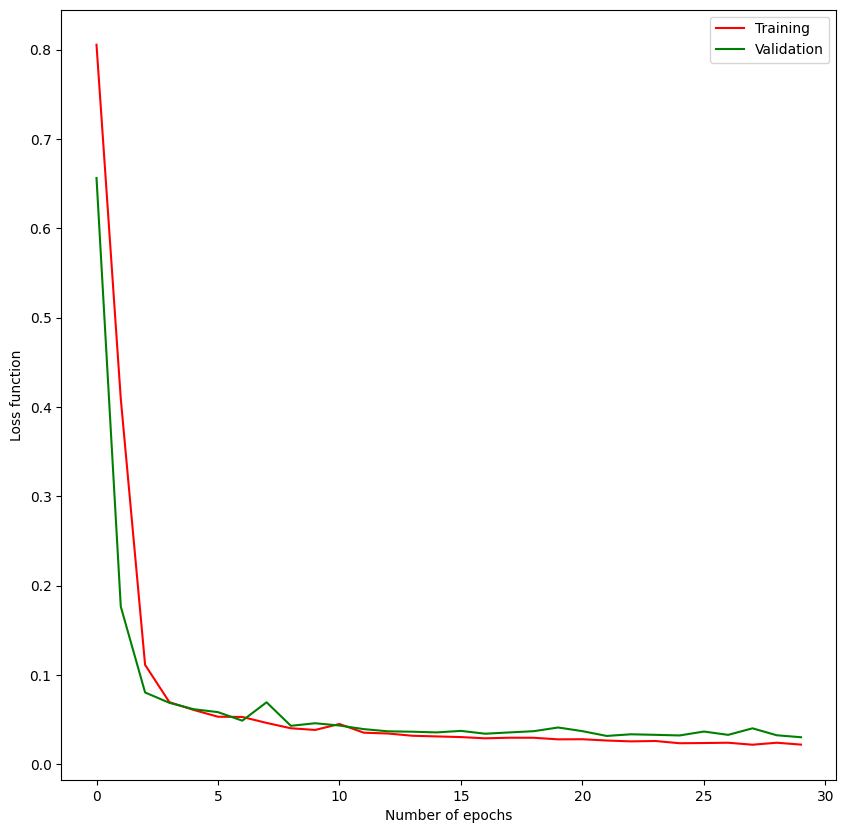

In [80]:
plt.figure(figsize = (10,10))
plt.xlabel('Number of epochs')
plt.ylabel('Loss function')
plt.plot(range(N_epochs), train_loss, color = 'red', label = 'Training')
plt.plot(range(N_epochs), eval_loss, color = 'green', label = 'Validation')
plt.legend(fontsize = 10)
plt.show()

**Testing**

In [82]:
predictions = []
targets = []

with torch.no_grad():
  model.eval()
  for feature,label in test_loader:
    feature = feature.unsqueeze(1).float().to(device)
    label = label.float().to(device)
    output = model(feature)

    predictions.append(output.cpu())
    targets.append(label.cpu())

pred = torch.cat(predictions, dim=0).numpy()
real = torch.cat(targets, dim=0).numpy()

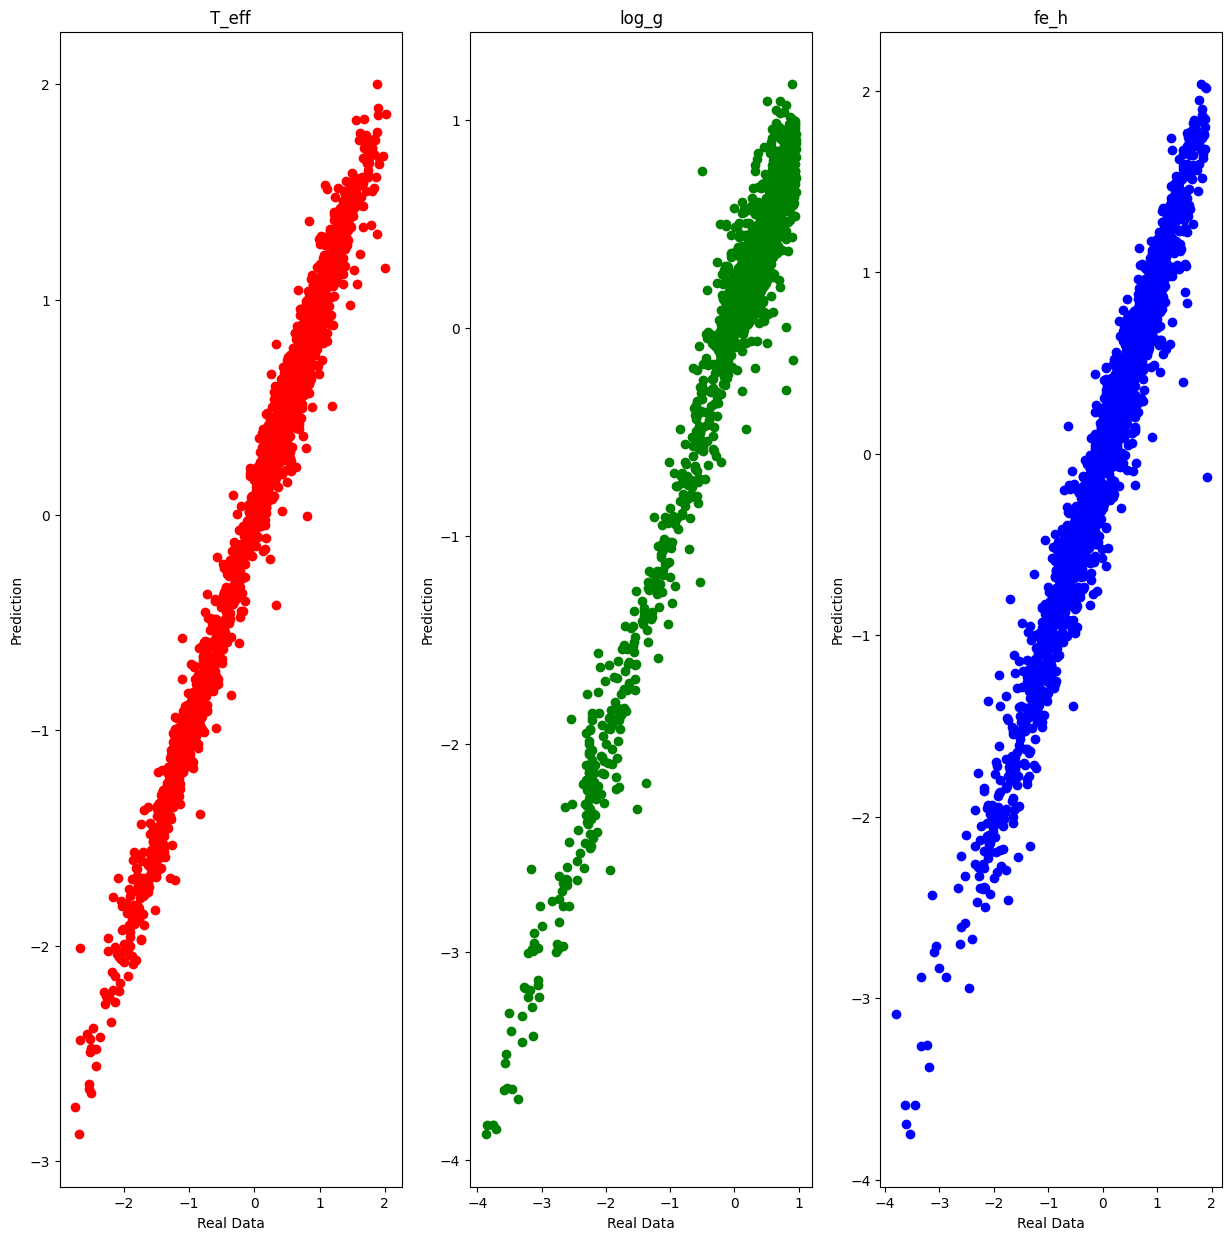

In [84]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (15,10))
ax = ax.flatten()

ax[0].set_xlabel('Real Data')
ax[0].set_ylabel('Prediction')
ax[0].set_title('T_eff')
ax[0].scatter(real[:,0],pred[:,0], color = 'red')

ax[1].set_xlabel('Real Data')
ax[1].set_ylabel('Prediction')
ax[1].set_title('log_g')
ax[1].scatter(real[:,1],pred[:,1], color = 'green')

ax[2].set_xlabel('Real Data')
ax[2].set_ylabel('Prediction')
ax[2].set_title('fe_h')
ax[2].scatter(real[:,2],pred[:,2], color = 'blue')

plt.show()

